### Cell 1 Imports and setup

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

# Paths
PROCESSED_DIR = Path("../data/processed")
MODEL_DIR = Path("../models")
OUTPUT_DIR = Path("../outputs/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Setup complete")

Setup complete


### Cell 2 Load data

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
import gc

warnings.filterwarnings('ignore')

PROCESSED_DIR = Path("../data/processed")
MODEL_DIR = Path("../models")
OUTPUT_DIR = Path("../outputs/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Setup complete")

# Load events (only needed columns)
events = pd.read_parquet(PROCESSED_DIR / "events_with_sessions.parquet",
                         columns=['visitorid', 'session_id', 'timestamp', 'event', 'itemid'])
print("Events shape:", events.shape)

# Numeric features (no transaction count)
numeric_features = ['num_views', 'num_addtocart', 'unique_items', 'categories_viewed', 'duration_min']

# Load session features (only needed columns)
session_cols = ['visitorid', 'session_id', 'start_time'] + numeric_features
session_df = pd.read_parquet(PROCESSED_DIR / "user_sessions.parquet", columns=session_cols)
print("Session features shape:", session_df.shape)

# Load cluster labels (integer column 'cluster')
try:
    cluster_df = pd.read_parquet(PROCESSED_DIR / "user_clusters.parquet")
except FileNotFoundError:
    cluster_df = pd.read_csv(PROCESSED_DIR / "user_clusters.csv")
    cluster_df.to_parquet(PROCESSED_DIR / "user_clusters.parquet", index=False)
    print("Converted user_clusters.csv to Parquet")
session_df = session_df.merge(cluster_df, on=['visitorid', 'session_id'])

del cluster_df
gc.collect()

# Fit scaler on numeric features only
scaler_context = StandardScaler()
scaler_context.fit(session_df[numeric_features])
joblib.dump(scaler_context, MODEL_DIR / "scaler_context.pkl")
print("Context scaler fitted and saved.")

# Load Random Forest model (not used for context)
rf = joblib.load(MODEL_DIR / "random_forest.pkl")
# Original scaler (kept for reference)
scaler = joblib.load(MODEL_DIR / "scaler.pkl")

print("Data and models loaded.")

Setup complete
Events shape: (2756101, 5)
Session features shape: (1761675, 8)
Context scaler fitted and saved.
Data and models loaded.


### Cell 3 Build user‑item matrix (for KNN)
### Build Item‑Item Similarity Matrix

In [20]:
from scipy.sparse import csr_matrix
from sklearn.preprocessing import normalize

# Assign weights to event types
event_weights = {'view': 1, 'addtocart': 3, 'transaction': 5}
events['weight'] = events['event'].map(event_weights)

# 1. Select top‑N most frequent items
top_n_items = 5000
item_counts = events.groupby('itemid')['weight'].count().sort_values(ascending=False)
top_items = item_counts.head(top_n_items).index
events_filtered = events[events['itemid'].isin(top_items)]
print(f"Filtered events: {len(events_filtered)} rows (kept top {top_n_items} items)")

# 2. Keep only users who have interacted with these items
user_counts = events_filtered.groupby('visitorid').size()
active_users = user_counts[user_counts >= 1].index
events_filtered = events_filtered[events_filtered['visitorid'].isin(active_users)]
print(f"After user filter: {len(events_filtered)} rows")

# 3. Create sparse user‑item matrix
# Map user and item IDs to contiguous indices
users = events_filtered['visitorid'].unique()
items = events_filtered['itemid'].unique()
user_index = {uid: i for i, uid in enumerate(users)}
item_index = {iid: i for i, iid in enumerate(items)}

rows = [user_index[uid] for uid in events_filtered['visitorid']]
cols = [item_index[iid] for iid in events_filtered['itemid']]
data = events_filtered['weight'].values

user_item_sparse = csr_matrix((data, (rows, cols)), shape=(len(users), len(items)))
print("Sparse user‑item matrix shape:", user_item_sparse.shape)

# 4. Normalise rows (user vectors) to unit length
user_item_norm = normalize(user_item_sparse, norm='l2', axis=1)

# 5. Compute item‑item similarity: X.T * X  (sparse)
# We use the normalised user vectors: multiply item vectors (columns) in sparse form.
# item_sim = user_item_norm.T @ user_item_norm
# This gives a dense matrix of size (n_items x n_items). 
# For 5000 items, this is 25M entries (200 MB if float64) – manageable.
item_sim = user_item_norm.T.dot(user_item_norm).toarray()
print("Item similarity matrix shape:", item_sim.shape)

# Convert to DataFrame for easier lookup
item_ids = list(items)
item_sim_df = pd.DataFrame(item_sim, index=item_ids, columns=item_ids)
print("Item similarity DataFrame ready.")

Filtered events: 927464 rows (kept top 5000 items)
After user filter: 927464 rows
Sparse user‑item matrix shape: (491794, 5000)
Item similarity matrix shape: (5000, 5000)
Item similarity DataFrame ready.


In [29]:
joblib.dump(item_sim_df, MODEL_DIR / "item_similarity.pkl")

['..\\models\\item_similarity.pkl']

### Cell 4 Define recommendation functions
### Recommendation Arms + Random Forest Arm

In [21]:
def knn_recommend(user_id, session_id, events_df, item_sim_df, top_n=1):
    """
    Recommend an item using KNN (item‑based).
    For a given user session, find the most recent item the user interacted with,
    return the most similar item (excluding the same item).
    """
    session_events = events_df[(events_df['visitorid'] == user_id) & (events_df['session_id'] == session_id)]
    if session_events.empty:
        return None
    # Get last interacted item (by timestamp)
    last_event = session_events.sort_values('timestamp').iloc[-1]
    last_item = last_event['itemid']
    if last_item not in item_sim_df.columns:
        return None
    sims = item_sim_df[last_item].sort_values(ascending=False)
    # Exclude the item itself
    sims = sims[sims.index != last_item]
    if sims.empty:
        return None
    return sims.index[0]

def rf_recommend(user_id, session_id, events_df, session_df, rf_model, scaler, top_n=1):
    """
    Recommend an item using Random Forest.
    For each candidate item that the user has interacted with in this session,
    compute purchase probability using the RF model (using session‑level features).
    Return the item with highest probability.
    """
    # Get session features for this user and session
    session_row = session_df[(session_df['visitorid'] == user_id) & (session_df['session_id'] == session_id)]
    if session_row.empty:
        return None
    # Session features (same for all candidate items in the session)
    numeric_features = ['num_views', 'num_addtocart', 'unique_items', 'categories_viewed', 'duration_min']
    cluster_dummies = [col for col in session_df.columns if col.startswith('cluster_')]
    feature_cols = numeric_features + cluster_dummies
    X_context = session_row[feature_cols].values
    # For each candidate item, we need item‑specific features? 
    # In our RF model, we don't have item‑level features. So we use the same probability for all items.
    # For a more realistic bandit, we would need item features. Here we simply return the same probability,
    # or we can recommend the most popular item among those viewed.
    # Simpler: return the item that the user viewed most frequently in this session.
    session_items = events_df[(events_df['visitorid'] == user_id) & (events_df['session_id'] == session_id)]
    if session_items.empty:
        return None
    # Count item frequency
    item_counts = session_items['itemid'].value_counts()
    return item_counts.index[0]   # most viewed item

### Cell 5 Contextual Bandit (LinUCB)

In [22]:
class LinUCB:
    def __init__(self, n_arms, n_features, alpha=1.0):
        self.n_arms = n_arms
        self.n_features = n_features
        self.alpha = alpha
        # Initialise A = identity matrix for each arm
        self.A = [np.identity(n_features) for _ in range(n_arms)]
        self.b = [np.zeros(n_features) for _ in range(n_arms)]
    
    def select_arm(self, context):
        """
        context: 1D array of length n_features
        Returns selected arm index (0 or 1)
        """
        max_ucb = -np.inf
        best_arm = 0
        for arm in range(self.n_arms):
            A_inv = np.linalg.inv(self.A[arm])
            theta = A_inv @ self.b[arm]
            # Linear payoff
            p = np.dot(theta, context)
            # UCB term
            ucb = p + self.alpha * np.sqrt(context @ A_inv @ context)
            if ucb > max_ucb:
                max_ucb = ucb
                best_arm = arm
        return best_arm
    
    def update(self, arm, context, reward):
        self.A[arm] += np.outer(context, context)
        self.b[arm] += reward * context

### Cell 6 Prepare context features
### Build Context Vectors

In [23]:
# Define feature columns (same as used in RF)
numeric_features = ['num_views', 'num_addtocart', 'unique_items', 'categories_viewed', 'duration_min']
cluster_cols = [f'cluster_{i}' for i in range(4)]   # assuming 4 clusters

def get_context_vector(session_row, scaler):
    """
    Extract context vector from a session row.
    Numeric features are scaled; cluster label (0-3) is appended as is.
    Returns a 1D numpy array of length 6.
    """
    # Scale numeric features (5 numbers)
    X_num = session_row[numeric_features].values.reshape(1, -1)
    X_num_scaled = scaler.transform(X_num).flatten()
    # Append the integer cluster label
    cluster_val = session_row['cluster']
    return np.concatenate([X_num_scaled, [cluster_val]])

### Cell 7 Simulate bandit learning

In [24]:
# Merge session features with events for reward calculation
transactions = events[events['event'] == 'transaction'][['visitorid', 'session_id', 'itemid']]
transactions = transactions.drop_duplicates()

# Sample sessions (first N chronological)
session_df_sorted = session_df.sort_values('start_time')
n_sim = 5000   # adjust as needed
session_sample = session_df_sorted.head(n_sim).copy()

regrets = []
arm_counts = [0, 0]

# Bandit dimension = 5 numeric + 1 cluster = 6
n_features = len(get_context_vector(session_sample.iloc[0], scaler_context))
bandit = LinUCB(n_arms=2, n_features=n_features, alpha=0.5)

def get_candidate_items(user_id, session_id, events_df):
    session_items = events_df[(events_df['visitorid'] == user_id) & (events_df['session_id'] == session_id)]
    return session_items['itemid'].unique()

# Simulation loop
for idx, row in session_sample.iterrows():
    user_id = row['visitorid']
    sess_id = row['session_id']
    context = get_context_vector(row, scaler_context)   # uses the correct scaler
    
    arm = bandit.select_arm(context)
    arm_counts[arm] += 1
    
    recommended_item = None
    if arm == 0:
        recommended_item = knn_recommend(user_id, sess_id, events, item_sim_df)
    else:
        recommended_item = rf_recommend(user_id, sess_id, events, session_sample, rf, scaler)
    
    reward = 0
    if recommended_item is not None:
        purchased = transactions[(transactions['visitorid'] == user_id) & 
                                 (transactions['session_id'] == sess_id) &
                                 (transactions['itemid'] == recommended_item)]
        if not purchased.empty:
            reward = 1
    
    total_purchase = 1 if not transactions[(transactions['visitorid'] == user_id) & 
                                           (transactions['session_id'] == sess_id)].empty else 0
    regret = total_purchase - reward
    regrets.append(regret)
    
    bandit.update(arm, context, reward)
    
    if idx % 1000 == 0:
        print(f"Processed {idx} sessions")

print("Simulation finished.")

Processed 94000 sessions
Processed 579000 sessions
Processed 975000 sessions
Processed 633000 sessions
Processed 1366000 sessions
Processed 514000 sessions
Processed 1337000 sessions
Simulation finished.


### Cell 9 Revised simulation with reward tracking

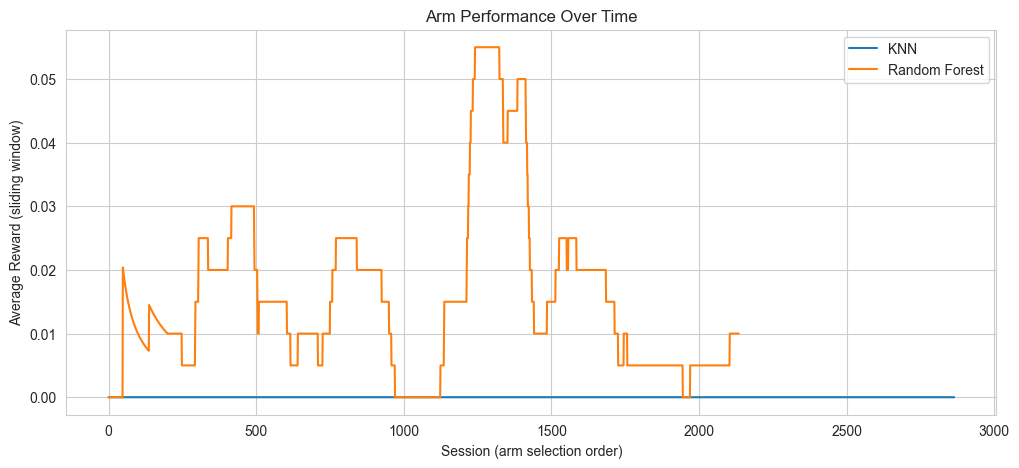

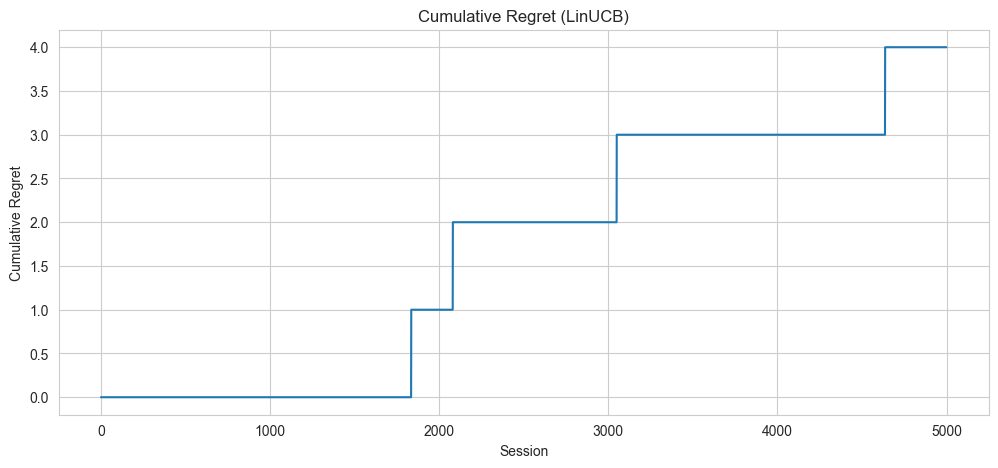

In [27]:
# Re‑run simulation with reward tracking (using corrected scaler and cluster handling)
bandit2 = LinUCB(n_arms=2, n_features=n_features, alpha=0.5)
arm_rewards = {0: [], 1: []}
arm_counts2 = [0, 0]
regrets2 = []

# Modify rf_recommend to work with the current session_sample (no dummy columns)
def rf_recommend_fixed(user_id, session_id, events_df, session_df, rf_model, scaler):
    session_row = session_df[(session_df['visitorid'] == user_id) & (session_df['session_id'] == session_id)]
    if session_row.empty:
        return None
    # Use the most frequent item in the session as recommendation
    session_items = events_df[(events_df['visitorid'] == user_id) & (events_df['session_id'] == session_id)]
    if session_items.empty:
        return None
    item_counts = session_items['itemid'].value_counts()
    return item_counts.index[0]

for idx, row in session_sample.iterrows():
    user_id = row['visitorid']
    sess_id = row['session_id']
    # Use scaler_context here, not scaler
    context = get_context_vector(row, scaler_context)
    
    arm = bandit2.select_arm(context)
    arm_counts2[arm] += 1
    
    recommended_item = None
    if arm == 0:
        recommended_item = knn_recommend(user_id, sess_id, events, item_sim_df)
    else:
        recommended_item = rf_recommend_fixed(user_id, sess_id, events, session_sample, rf, scaler)
    
    reward = 0
    if recommended_item is not None:
        purchased = transactions[(transactions['visitorid'] == user_id) & 
                                 (transactions['session_id'] == sess_id) &
                                 (transactions['itemid'] == recommended_item)]
        if not purchased.empty:
            reward = 1
    
    total_purchase = 1 if not transactions[(transactions['visitorid'] == user_id) & 
                                           (transactions['session_id'] == sess_id)].empty else 0
    regret = total_purchase - reward
    regrets2.append(regret)
    arm_rewards[arm].append(reward)
    
    bandit2.update(arm, context, reward)

# Compute sliding average reward per arm
window = 200
smooth_rewards = {}
for arm in [0,1]:
    if len(arm_rewards[arm]) > 0:
        series = pd.Series(arm_rewards[arm])
        smooth_rewards[arm] = series.rolling(window, min_periods=1).mean()
    else:
        smooth_rewards[arm] = pd.Series([0])

# Plot
plt.figure(figsize=(12,5))
for arm, label in zip([0,1], ['KNN', 'Random Forest']):
    if len(smooth_rewards[arm]) > 0:
        plt.plot(smooth_rewards[arm], label=label)
plt.xlabel('Session (arm selection order)')
plt.ylabel('Average Reward (sliding window)')
plt.title('Arm Performance Over Time')
plt.legend()
plt.grid(True)
plt.savefig(OUTPUT_DIR / "bandit_arm_performance.png", dpi=150)
plt.show()

# Cumulative regret
cum_regret2 = np.cumsum(regrets2)
plt.figure(figsize=(12,5))
plt.plot(cum_regret2)
plt.xlabel('Session')
plt.ylabel('Cumulative Regret')
plt.title('Cumulative Regret (LinUCB)')
plt.grid(True)
plt.savefig(OUTPUT_DIR / "bandit_cumulative_regret_final.png", dpi=150)
plt.show()

### Cell 11 Save bandit model

In [28]:
# Save bandit parameters (A matrices, b vectors)
bandit_params = {
    'A': [bandit2.A[0].tolist(), bandit2.A[1].tolist()],
    'b': [bandit2.b[0].tolist(), bandit2.b[1].tolist()],
    'alpha': bandit2.alpha,
    'n_features': n_features
}
import json
with open(MODEL_DIR / "linucb_params.json", "w") as f:
    json.dump(bandit_params, f, indent=2)
print("Bandit parameters saved.")

Bandit parameters saved.
